# Evaluation der Mapping-Annotation

Dieses Notebook wertet die manuell annotierten HD→IPA-Mapping-Kandidaten aus. Ziel ist der Vergleich der drei Matching-Methoden:

- Greedy/PMI
- Positional
- IBM/EM

Die zentrale Metrik ist Precision@1 auf den annotierten Top-1-Mappings. Unsichere Fälle (`?`) werden in der Hauptmetrik ausgeschlossen und zusätzlich separat ausgewiesen.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "Data"

ANNOTATION_CSV = DATA_DIR / "annotation_candidates.csv"
METHOD_SUMMARY_CSV = DATA_DIR / "evaluation_method_summary.csv"
CONSENSUS_SUMMARY_CSV = DATA_DIR / "evaluation_consensus_summary.csv"
ERROR_EXAMPLES_CSV = DATA_DIR / "evaluation_error_examples.csv"

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 140)

## Daten Laden

In [2]:
annotations = pd.read_csv(ANNOTATION_CSV, keep_default_na=False)
method_summary = pd.read_csv(METHOD_SUMMARY_CSV)
consensus_summary = pd.read_csv(CONSENSUS_SUMMARY_CSV)
error_examples = pd.read_csv(ERROR_EXAMPLES_CSV, keep_default_na=False)

annotations["correct"] = annotations["correct"].astype(str).str.strip()

print(f"Annotationen: {len(annotations)}")
print(f"Offen: {(annotations['correct'] == '').sum()}")
print(f"Korrekt: {(annotations['correct'] == '1').sum()}")
print(f"Falsch: {(annotations['correct'] == '0').sum()}")
print(f"Unsicher: {(annotations['correct'] == '?').sum()}")

Annotationen: 241
Offen: 0
Korrekt: 190
Falsch: 37
Unsicher: 14


## Methodenergebnis

`precision_excluding_unclear` ist die Hauptmetrik: unsichere Fälle werden nicht als falsch gezählt, sondern aus dem Nenner entfernt. `precision_unclear_as_wrong` ist eine konservative Zusatzmetrik.

In [3]:
display(
    method_summary.assign(
        coverage_unique_hd_total=lambda df: df["coverage_unique_hd_total"].round(3),
        precision_excluding_unclear=lambda df: df["precision_excluding_unclear"].round(3),
        precision_unclear_as_wrong=lambda df: df["precision_unclear_as_wrong"].round(3),
    )
)

,method,candidates,unique_hd,coverage_unique_hd_total,judged,correct,wrong,unclear,precision_excluding_unclear,precision_unclear_as_wrong
0,Greedy/PMI,115,115,0.525,110,102,8,5,0.927,0.887
1,Positional,185,185,0.845,178,151,27,7,0.848,0.816
2,IBM/EM,143,143,0.653,136,124,12,7,0.912,0.867


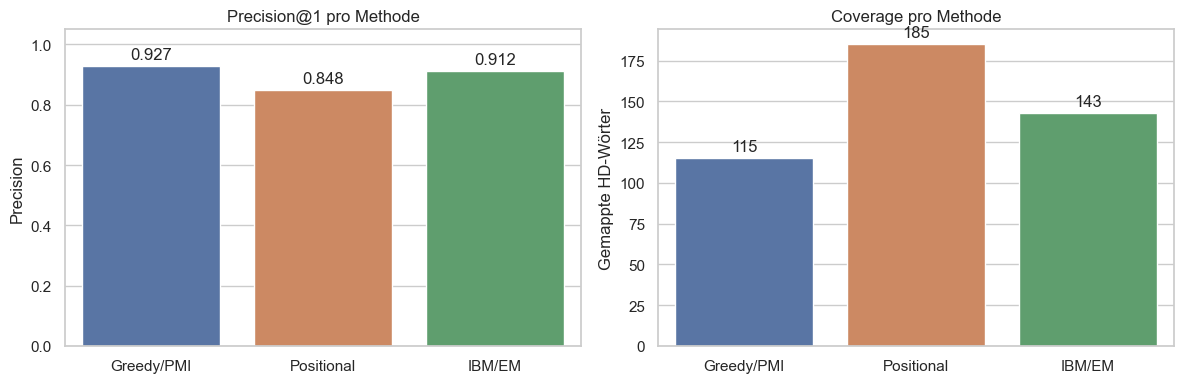

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(
    data=method_summary,
    x="method",
    y="precision_excluding_unclear",
    hue="method",
    dodge=False,
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Precision@1 pro Methode")
axes[0].set_xlabel("")
axes[0].set_ylabel("Precision")
axes[0].set_ylim(0, 1.05)

for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.3f", padding=3)

sns.barplot(
    data=method_summary,
    x="method",
    y="unique_hd",
    hue="method",
    dodge=False,
    legend=False,
    ax=axes[1],
)
axes[1].set_title("Coverage pro Methode")
axes[1].set_xlabel("")
axes[1].set_ylabel("Gemappte HD-Wörter")

for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.0f", padding=3)

plt.tight_layout()
plt.show()

## Konsens Der Methoden

Hier sieht man, wie zuverlässig Mappings sind, wenn sie von mehreren Methoden gleichzeitig vorgeschlagen wurden.

In [5]:
display(
    consensus_summary.assign(
        precision_excluding_unclear=lambda df: df["precision_excluding_unclear"].round(3)
    )
)

,method_count,methods,total,judged,correct,wrong,unclear,precision_excluding_unclear
0,3,"greedy, positional, ibm",71,70,69,1,1,0.986
1,2,"greedy, ibm",41,38,32,6,3,0.842
2,2,"positional, ibm",19,19,17,2,0,0.895
3,1,positional,95,89,65,24,6,0.730
4,1,ibm,12,9,6,3,3,0.667
5,1,greedy,3,2,1,1,1,0.500


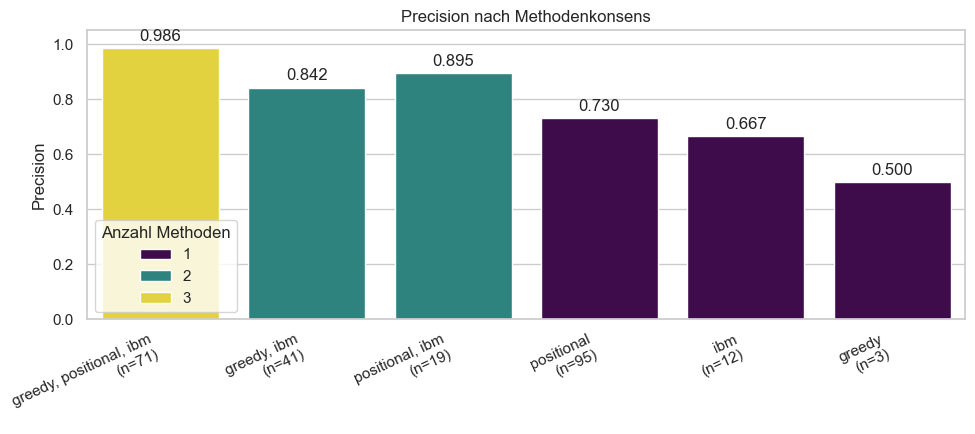

In [6]:
plot_df = consensus_summary.copy()
plot_df["group"] = plot_df["methods"] + "\n(n=" + plot_df["total"].astype(str) + ")"

plt.figure(figsize=(10, 4.5))
ax = sns.barplot(
    data=plot_df,
    x="group",
    y="precision_excluding_unclear",
    hue="method_count",
    dodge=False,
    palette="viridis",
)
ax.set_title("Precision nach Methodenkonsens")
ax.set_xlabel("")
ax.set_ylabel("Precision")
ax.set_ylim(0, 1.05)
ax.legend(title="Anzahl Methoden", loc="lower left")
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## Korrektheit Nach Anzahl Methoden

Diese Tabelle verdichtet die Frage: Werden Mappings zuverlässiger, wenn mehrere Methoden übereinstimmen?

In [7]:
by_method_count = (
    annotations.groupby(["method_count", "correct"])
    .size()
    .unstack(fill_value=0)
    .rename(columns={"1": "correct", "0": "wrong", "?": "unclear"})
    .reset_index()
)

for col in ["correct", "wrong", "unclear"]:
    if col not in by_method_count.columns:
        by_method_count[col] = 0

by_method_count["judged"] = by_method_count["correct"] + by_method_count["wrong"]
by_method_count["precision"] = by_method_count["correct"] / by_method_count["judged"]
display(by_method_count[["method_count", "correct", "wrong", "unclear", "judged", "precision"]].round(3))

correct,method_count,correct,wrong,unclear,judged,precision
0,1,72,28,10,100,0.720
1,2,49,8,3,57,0.860
2,3,69,1,1,70,0.986


## Fehleranalyse

Für die Arbeit reichen wenige typische Fehlerbeispiele. Sinnvoll sind Fälle, die trotz hoher Evidenz falsch sind oder wo nur eine Methode ein Paar vorgeschlagen hat.

In [8]:
display(error_examples.head(20))

,id,Hochdeutsch,IPA_Dialekt,methods,example_sentence,example_ipa_audio,example_ipa_reference,comment
0,31,dafür,fyːɾ,"greedy, positional, ibm",Dafür wurde er mit der Fields-Medaille ausgezeichnet.,dɑːrdɛ fyːɾ ɪn ɪn dɛn fiːlt mɪdɛlɾiː aʊstsaɪçnət vɑːrdən,dɑːfyːɾ vʊɐdə ɛɾ mɪt dɛɾ fiːltsmeːdalɪə aʊsɡətsaɪçnət,Dafür wäre dɑːrdɛ fyːɾ
1,78,wurden,zɪnt,"greedy, ibm",Allerdings wurden die Sicherheitsvorkehrungen verstärkt.,ɑlə dɪŋ zɪnt zɪçɑːts vɔːkɪːgə fɛɾstɛɾkkt vɔːdən,alɜdɪŋs vʊɐdən diː zɪçɜhaɪtsfoːɾkeːrʊŋən fɛɾʃtɛɾkt,wurden -> zɪnt vɔːdən also sind worde
2,84,damit,mɪt,"greedy, ibm",Damit wurde wieder das hohe Niveau vom April erreicht.,dɑːdə mɪt ɪn ʃviːdɛs hoːxɛrniːvoː fɔm aːbɾiːləraɪçt vɔːdə,dɑːmɪt vʊɐdə viːdɜ das hoːə niːvoː fɔm apɾiːl ɛɾraɪçt,Damit -> dɑːdə mɪt
3,85,davon,foː,"greedy, ibm",Hier ist ein ganzer Band davon.,dɔɾ ɪʃən gantsə baʊnt də foː,hiːɾ ɪst aɪn ɡantsɜ bant dɑːfɔn,də foː
4,87,einem,ɪm,"greedy, ibm",In einem Konflikt wären all ihre wunden Punkte sichtbar geworden.,ɪm nɛk kɔmflɪkt vɛɾət ɑːl ɪçə vʊndə pʊŋkt sɪçpaːl kvɔːdə,ɪn aɪnəm kɔnflɪkt vɛːrən al iːrə vʊndən pʊŋktə zɪçtbɑːɾ ɡəvɔɾdən,
5,111,trotzdem,dɛm,"greedy, ibm",In der Schweiz gibt es für mich trotzdem auch einen König.,aɪ dɛɾ ʃviːtskiːts fyːɾ mɪç trɔts dɛm aʊən kœnɪç,ɪn dɛɾ ʃvaɪts ɡiːpt ɛs fyːɾ mɪç tɾɔtsdeːm aʊx aɪnən køːnɪç,trotzdem -> trɔts dɛm
6,75,dabei,biː,"greedy, ibm",Dabei sind wir zu keinem vernünftigen Schluss gekommen.,dɛɾ biː zimə tsuː kaɪn fɔnœftɪgə ʃluːs koː,dɑːbaɪ zɪnt viːɾ tsuː kaɪnəm fɛɾnʏnftɪɡən ʃlʊs ɡəkɔmən,Dabei wäre dɛɾ biː
7,121,deshalb,dɛs,"positional, ibm",Das iranische Aussenministerium bestellte deshalb den saudi-arabischen Botschafter ein.,siːraːnɪçə ʊsəmiːnɪçtəɾiːʊm hɪt dɾʊŋ dɛs aʊdɪɾaːpɪʃpɔtʃaɾ fɔɾ tɛlt ɛbʃtɛlt,das iːrɑnɪʃə aʊszɛnmiːnɪsteːriːʊm bəʃtɛltə dɛshalp deːn zaʊdiːarɑbɪʃən bɔtʃaftɜ aɪn,deshalb -> dɾʊŋ
8,122,dieser,dɛɾ,"positional, ibm",Gleichzeitig wird die Pikettorganisation während dieser Zeit entlastet.,gliːxtsiːtɪg viːɾt piːkə aʊɐganiːzatsiːɔːn vɛɾɾɛt tɛrə tsiːt dɛɾ klaɪʃtət,ɡlaɪçtsaɪtɪç vɪɾt diː piːkɛtɔɾɡaniːzatsjoːn vɛːrənt diːzɜ tsaɪt ɛntlastət,dieser -> tɛrə
9,133,wurde,ɪç,greedy,Ein weiterer Mann wurde im Rahmen einer Fahndung identifiziert und gestellt.,ɛn vɪktərə mɑːɾ ɪç ɪm rɑːmə fɔnɔxfɑːndɪç iːdɛntifiːɾt ʊntgʃtɛlt vɔɾdə,aɪn vaɪtərɜ man vʊɐdə ɪm rɑːmən aɪnɜ fɑːndʊŋ iːdəntiːfiːtsiːɾt ʊnt ɡəʃtɛlt,wurde -> ɪç vɔɾdə


In [9]:
wrong = annotations[annotations["correct"] == "0"].copy()
wrong_by_methods = (
    wrong.groupby("methods")
    .size()
    .sort_values(ascending=False)
    .reset_index(name="wrong_count")
)
display(wrong_by_methods)

,methods,wrong_count
0,positional,24
1,"greedy, ibm",6
2,ibm,3
3,"positional, ibm",2
4,greedy,1
5,"greedy, positional, ibm",1


## Unsichere Fälle

In [10]:
unclear_cols = [
    "id",
    "Hochdeutsch",
    "IPA_Dialekt",
    "methods",
    "example_sentence",
    "example_ipa_audio",
    "comment",
]
display(annotations.loc[annotations["correct"] == "?", unclear_cols])

,id,Hochdeutsch,IPA_Dialekt,methods,example_sentence,example_ipa_audio,comment
46,47,immer,ɪm,"greedy, positional, ibm","Ich äussere mich dazu, weil die Befangenheitsdiskussion immer wieder ein Argument ist.",ɪç øsəɾ mɪçtə tswɛl vɪlt bəfɑːŋəhaɪts diːs kɔsɪʊn ɪm ɛviːdɛɾ ɛs ɑːgʊmɛntɪʃ,
75,76,war,ɪç,"greedy, ibm",Dies war günstig und mit geringen Risiken behaftet.,ɛs ɪç gʏnst ɪksɪgə siː ʊnt mɪt gɛlgən riːzɪkɾoːbɛlf dɛt,war -> ɪç siː also isch gsieh
97,98,also,zoː,"greedy, ibm",Kann sie sich also schon unterhalten?,kɑsiːzɪç ɑːlt zoː ʃoː ʊndɛhaltə,also -> ɑːlt zoː
99,100,diesem,dɛm,"greedy, ibm","Den Fraktionsberichten kann man entnehmen, dass diesem Budget alle Partien zustimmen können.",ɪn frɑktɪoːnt bɾɪçt kɑmɑːɾ ɪnt neː dɛm byːtʃɪ ɑːliː pɑːtaɪɛ tsuːɛʃtiːmə ɦœnd,
133,134,konnte,kœnə,greedy,Man konnte auf anderweitige Erfahrungen zurückgreifen.,meː hɛːd ɔf andərʋiːtɪgə ɛvaɪgə kœnə tsɾʊç gɾɛːfər,konnte -> hɛːd kœnə
156,157,an,aɪdə,positional,An den Häfen drohten Chaos und Staus.,aɪdə hɛfə hɪnkaʊz ʃtaʊstɾʊt,An den -> aɪdə
164,165,bundesrat,bʊndəs,positional,Der Bundesrat lehnt ein solches Verbot ab.,ɪtə bʊndəs rɔɾt leːnt ɛs vøːtlɪks fɛɾbɔɾt ap,bundesrat -> bʊndəs rɔɾt
168,169,davon,fɔr,positional,Als Folge davon könne er weder Mitleid noch Gefühle entwickeln.,ɑz fʊlk fɔr dɛm kɔn jɛɾ vɪɾ dɛmɪdlɛɪdən ɑp fyːlɪnt viːklə,davon -> fɔr dɛm
189,190,irgendwie,viːɾ,positional,Sie wirken irgendwie fehl am Platz.,tsiː viːɾkɾətiːrəkən viːɾ fɛləm blats,
190,191,knowhow,noʊ,positional,Dieses Know-how fliesst auch in die Smartphones der Hersteller ein.,aɪl noʊ hɑfliːsɛlb ɪts nɑɹts foʊndz fʊɐ dɛɹ hɛɹ ʃtɛlə iː,Know -> noʊ


## Kurzfazit Für Den Bericht

In [11]:
best_precision = method_summary.sort_values("precision_excluding_unclear", ascending=False).iloc[0]
best_coverage = method_summary.sort_values("unique_hd", ascending=False).iloc[0]
all_three = consensus_summary[consensus_summary["method_count"] == 3].iloc[0]

print(
    f"Die höchste Precision erreicht {best_precision['method']} "
    f"mit {best_precision['precision_excluding_unclear']:.3f}."
)
print(
    f"Die höchste Coverage erreicht {best_coverage['method']} "
    f"mit {int(best_coverage['unique_hd'])} gemappten HD-Wörtern."
)
print(
    f"Wenn alle drei Methoden dasselbe Paar vorschlagen, liegt die Precision bei "
    f"{all_three['precision_excluding_unclear']:.3f} "
    f"({int(all_three['correct'])}/{int(all_three['judged'])} korrekt bewertete Fälle)."
)

Die höchste Precision erreicht Greedy/PMI mit 0.927.
Die höchste Coverage erreicht Positional mit 185 gemappten HD-Wörtern.
Wenn alle drei Methoden dasselbe Paar vorschlagen, liegt die Precision bei 0.986 (69/70 korrekt bewertete Fälle).
